<a href="https://colab.research.google.com/github/adityajain9756-rgb/ecommerce-sales-analysis/blob/main/EDA_aditya_amazon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -Exploratory Data Analysis of Amazon E-Commerce Sales



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name** - Aditya Jain


# **Project Summary -**

This project performs **Exploratory Data Analysis (EDA)** on an Amazon Sales Report dataset to gain insights into sales performance, product demand, order fulfillment, and customer purchasing trends. The analysis includes data cleaning, handling missing values, identifying patterns, and visualizing key business metrics.

The project aims to uncover valuable insights such as top-performing product categories, sales trends, regional performance, order status distribution, and the impact of fulfillment methods. These findings can help improve inventory management, optimize sales strategies, and support data-driven business decisions for an e-commerce business.


# **GitHub Link -**

https://github.com/adityajain9756-rgb/ecommerce-sales-analysis.git

# **Problem Statement**


In the highly competitive e-commerce industry, understanding sales performance and customer purchasing behavior is essential for business growth. Amazon generates a large volume of transactional data containing information about orders, products, fulfillment methods, shipping locations, and sales. However, raw data alone does not provide actionable insights.

The challenge is to analyze this sales data to identify sales trends, top-performing product categories, regional demand, order fulfillment efficiency, and factors influencing business performance. By performing Exploratory Data Analysis (EDA), the objective is to transform raw transactional data into meaningful insights that can support better decision-making, improve operational efficiency, optimize inventory management, and enhance customer satisfaction.


#### **Define Your Business Objective?**

The primary objective of this project is to analyze Amazon sales data to understand customer purchasing patterns, product performance, sales trends, and order fulfillment efficiency. Through Exploratory Data Analysis (EDA), the project aims to identify top-selling product categories, evaluate regional sales performance, analyze order status and fulfillment methods, and uncover key factors influencing sales. The insights generated from this analysis will help support data-driven decisions for improving inventory management, optimizing sales strategies, enhancing customer satisfaction, and increasing overall business performance.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [56]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

### Dataset Loading

In [57]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Amazon Sale Report.csv",low_memory=False)
df.drop(columns=["Unnamed: 22"], inplace=True) #as this column is completelly empty

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset First View

In [58]:
# Dataset First Look
# Display all columns
pd.set_option('display.max_columns', None)
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN


### Dataset Rows & Columns count

In [59]:
# Dataset Rows & Columns count
df.shape

(128975, 23)

### Dataset Information

In [60]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

#### Duplicate Values

In [61]:
# Dataset Duplicate Value Count
duplicate_row_count = df.duplicated().sum()
print(duplicate_row_count)

0


#### Missing Values/Null Values

In [62]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()
print(missing_values)

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
dtype: int64


Text(0, 0.5, 'Columns')

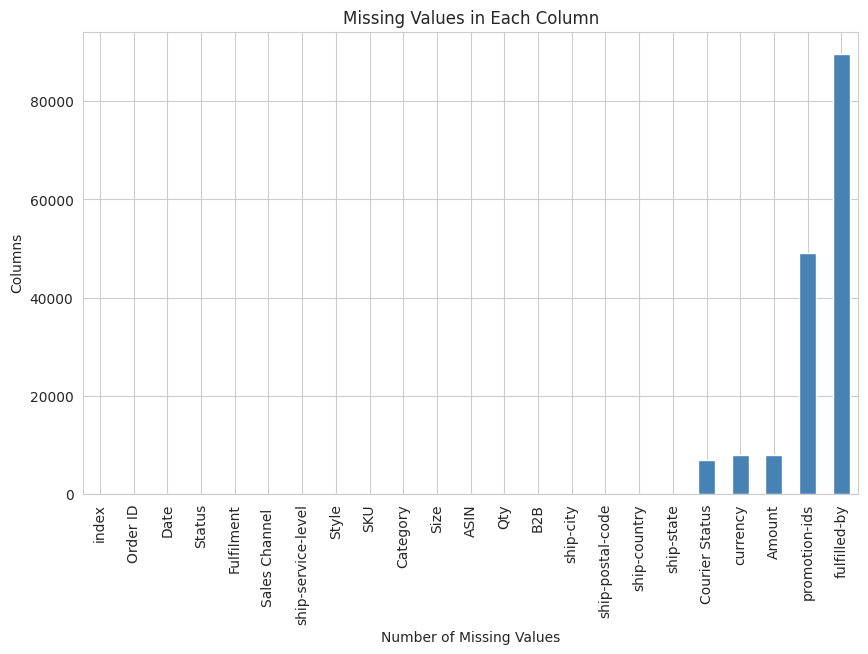

In [63]:
# Visualizing the missing values
plt.figure(figsize=(10,6))
missing_values.sort_values().plot(kind='bar', color='steelblue')

plt.title('Missing Values in Each Column')
plt.xlabel('Number of Missing Values')
plt.ylabel('Columns')


### What did you know about your dataset?

* The dataset contains Amazon e-commerce sales transaction records, providing information about orders, products, sales amounts, fulfillment methods, shipping details, and order status.
* It consists of approximately **128,000+ records** and **24 columns**, making it suitable for detailed exploratory data analysis.
* The dataset includes both **categorical variables** (such as Category, Status, Fulfilment, Ship State, Ship City, Size, and Courier Status) and **numerical variables** (such as Quantity and Amount).
* Some columns contain missing values, particularly in shipping, courier, and sales-related fields, which require appropriate data cleaning before analysis.
* The dataset also contains an unnecessary column (`Unnamed: 22`) that is removed during preprocessing.
* Date information is available and can be used to analyze sales trends over time.
* Overall, the dataset provides sufficient information to analyze product performance, sales trends, regional demand, order fulfillment efficiency, and customer purchasing patterns, enabling meaningful business insights and recommendations.
Answer Here

## ***2. Understanding Variables***

In [64]:
# Dataset Columns
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')

In [65]:
# Dataset Describe
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


### Variables Description

* The dataset contains 128,975 order records.
* Customers usually purchase one item per order, as the median quantity is 1.
* The average order value is approximately ₹648.56, with values ranging from ₹0 to ₹5,584, indicating variation in purchase amounts.
* Shipping postal codes vary widely across the dataset, indicating that orders are placed from multiple geographic regions.
* The presence of 0 values in Qty and Amount may indicate cancelled, returned, or invalid orders and should be investigated during data cleaning.

### Check Unique Values for each variable.

In [66]:
# Check Unique Values for each variable.
for column in df.columns:
    unique_count = df[column].nunique()
    print(f"Column '{column}' has {unique_count} unique values.")

Column 'index' has 128975 unique values.
Column 'Order ID' has 120378 unique values.
Column 'Date' has 91 unique values.
Column 'Status' has 13 unique values.
Column 'Fulfilment' has 2 unique values.
Column 'Sales Channel ' has 2 unique values.
Column 'ship-service-level' has 2 unique values.
Column 'Style' has 1377 unique values.
Column 'SKU' has 7195 unique values.
Column 'Category' has 9 unique values.
Column 'Size' has 11 unique values.
Column 'ASIN' has 7190 unique values.
Column 'Courier Status' has 3 unique values.
Column 'Qty' has 10 unique values.
Column 'currency' has 1 unique values.
Column 'Amount' has 1410 unique values.
Column 'ship-city' has 8955 unique values.
Column 'ship-state' has 69 unique values.
Column 'ship-postal-code' has 9459 unique values.
Column 'ship-country' has 1 unique values.
Column 'promotion-ids' has 5787 unique values.
Column 'B2B' has 2 unique values.
Column 'fulfilled-by' has 1 unique values.


## 3. ***Data Wrangling***

### Data Wrangling Code

In [153]:
#Code to make dataset analysis ready.

# Create a copy of the dataset
df_clean = df.copy()

# Convert Date column into datetime format
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%m-%d-%y')

# Remove duplicate records
df_clean.drop_duplicates(inplace=True)

# Remove state name inconsistency
df_clean['ship-state'] = df_clean['ship-state'].str.strip().str.title()

# Fill missing values
df_clean['Courier Status'] = df_clean['Courier Status'].fillna('Unknown')
df_clean['currency'] = df_clean['currency'].fillna('INR')
df_clean['fulfilled-by'] = df_clean['fulfilled-by'].fillna('Unknown')

# Remove rows where sales amount is missing
df_clean.dropna(subset=['Amount'], inplace=True)

# Remove rows with missing shipping information
df_clean.dropna(subset=[
    'ship-city',
    'ship-state',
    'ship-postal-code',
    'ship-country'
], inplace=True)

# Reset index
df_clean.reset_index(drop=True, inplace=True)

# Verif missing values
df_clean.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


### What all manipulations have been done and insights found?

#### Manipulations:
* Created a copy of the original dataset to preserve the raw data.
* Converted the Date column to datetime format for time-based analysis.
* Removed duplicate records to ensure data consistency.
* Handled missing values by filling Courier Status, currency, and fulfilled-by with appropriate values.
* Removed records with missing Amount and essential shipping information, as these are critical for sales and regional analysis.
* Reset the index after cleaning to maintain a well-structured dataset.

#### Insights:

* The dataset contained missing values in a few key columns that required preprocessing.
* Most missing values were concentrated in promotion-ids and fulfilled-by, while only a small number of records had missing shipping details.
* After data wrangling, the dataset became clean, consistent, and ready for reliable exploratory data analysis.

## ***4. Data Visualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Type 1 - Business Overview Analysis

#### Chart - 1 - Order Status Distribution (Count Plot)


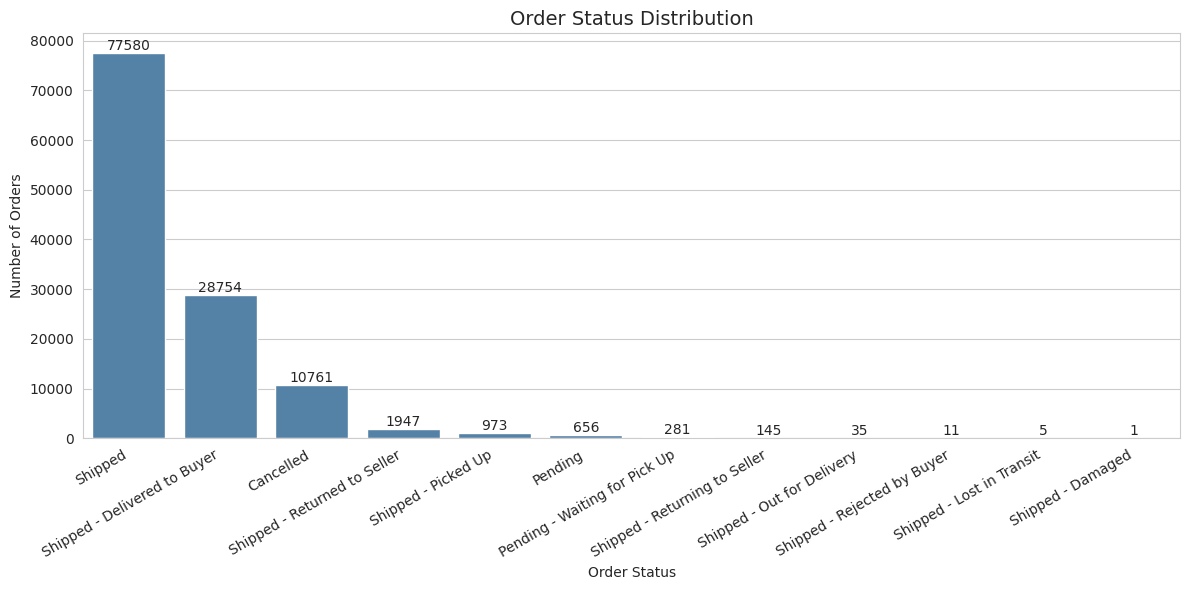

In [154]:
# Chart - 1 visualization code
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df_clean,
    x='Status',
    order=df_clean['Status'].value_counts().index,
    color='steelblue'
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Order Status Distribution', fontsize=14)
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because the Order Status variable is categorical. It clearly shows the frequency of each order status, making it easy to compare the number of shipped, cancelled, returned, and pending orders. This helps evaluate the overall order fulfillment performance of the business.

##### 2. What are the insights found from the chart?

* The majority of orders fall under the Shipped status, indicating that most orders were processed successfully.
* Shipped - Delivered to Buyer is the second most common status, reflecting successful order completion.
* Although the number of Cancelled orders is lower than shipped orders, it is still significant and may require further analysis.
* Other statuses such as Returned to Seller, Pending, Lost in Transit, and Damaged have comparatively fewer orders, suggesting that such cases occur less frequently.Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights from this chart help evaluate the efficiency of the order fulfillment process. A high proportion of shipped and delivered orders indicates effective operations and contributes to customer satisfaction. The presence of cancelled orders highlights opportunities to investigate issues such as inventory availability, order processing delays, or customer-related factors. Reducing cancellations and continuously monitoring other exceptional order statuses can improve operational efficiency, enhance customer experience, and support business growth.

#### Chart - 2 -  Monthly Sales Trend (Line Chart)

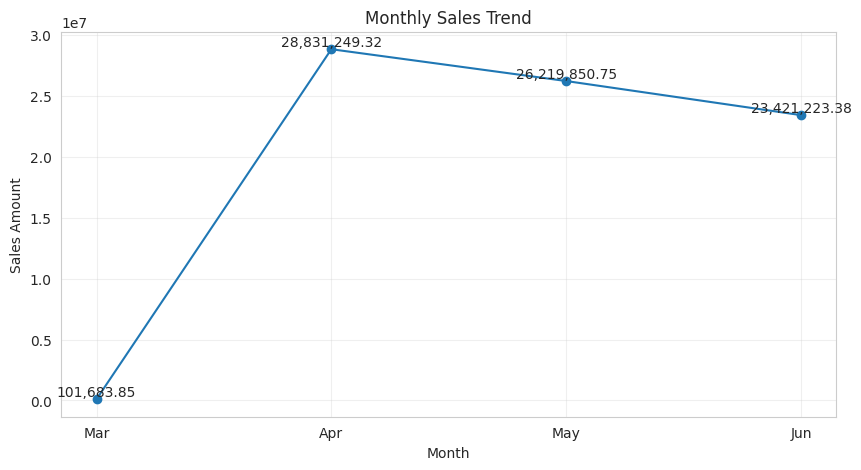

In [155]:
# Chart - 2 visualization code
# Extract month names
df_clean['Month'] = df_clean['Date'].dt.strftime('%b')

# Keep months in correct order
month_order = ['Mar', 'Apr', 'May', 'Jun']

monthly_sales = df_clean.groupby('Month')['Amount'].sum().reindex(month_order)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

# Show count on each point
for x, y in zip(monthly_sales.index, monthly_sales.values):
    plt.text(x, y, f'{y:,}', ha='center', va='bottom')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales Amount')

plt.grid(alpha=0.3)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen because it is the most effective way to visualize changes in sales over time. It clearly shows the monthly sales trend, making it easy to identify periods of growth or decline and understand overall business performance.

##### 2. What is/are the insight(s) found from the chart?

* Sales increased significantly from March to April, with April recording the highest sales during the observed period.
* After reaching its peak in April, sales showed a gradual decline in May and June, although they remained relatively high.
* The low sales in March are due to the dataset containing data only from March 31, 2022, making it an incomplete month and not directly comparable with the other months.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps identify monthly sales patterns and supports better business planning. The strong sales performance in April can be analyzed to understand the factors contributing to higher revenue and replicate those strategies in future months. The gradual decline in May and June suggests the need to review marketing campaigns, inventory management, or seasonal demand to maintain consistent sales growth.

#### Chart - 3 - Monthly Order Count (Line Chart)

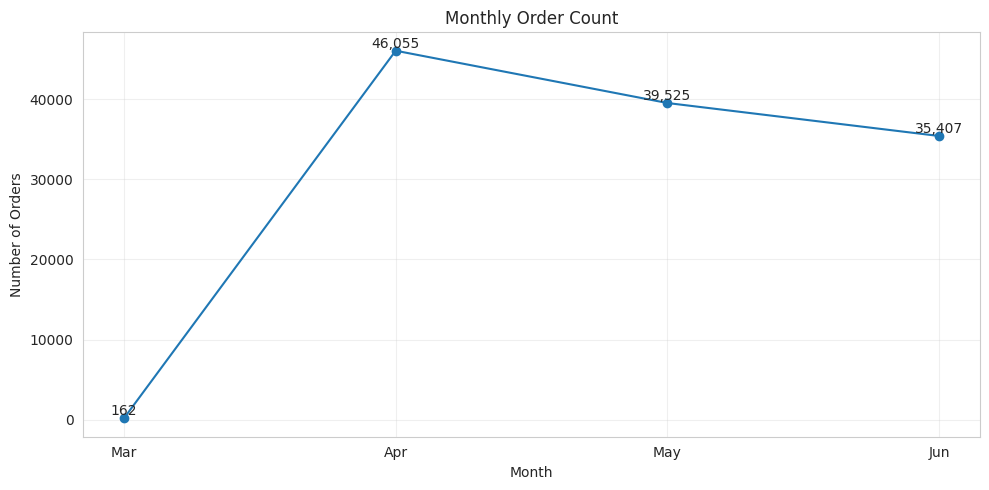

In [156]:
# Chart - 3 visualization code
df_clean['Month'] = df_clean['Date'].dt.strftime('%b')

month_order = ['Mar', 'Apr', 'May', 'Jun']

monthly_orders = df_clean.groupby('Month').size().reindex(month_order)

plt.figure(figsize=(10,5))

plt.plot(monthly_orders.index, monthly_orders.values, marker='o')

# Show count on each point
for x, y in zip(monthly_orders.index, monthly_orders.values):
    plt.text(x, y, f'{y:,}', ha='center', va='bottom')

plt.title('Monthly Order Count')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen because it effectively illustrates how the number of orders changes over time. It helps identify monthly demand patterns and makes it easy to observe increases or decreases in order volume.

##### 2. What is/are the insight(s) found from the chart?

* The chart shows the monthly trend in the number of orders placed during the analysis period.
* April recorded the highest number of orders, followed by a gradual decline in May and June.
* Since the dataset begins on March 31, the order count for March is significantly lower and should not be directly compared with the full months of April, May, and June.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Monitoring monthly order volume helps businesses understand customer demand and plan inventory, staffing, and logistics more effectively. Identifying months with higher order volumes supports better resource allocation, while recognizing periods of lower demand enables businesses to introduce targeted marketing campaigns and promotional offers to improve future sales.

### Type 2 -Product Analysis

#### Chart - 4 - Orders by Category (Bar Chart)




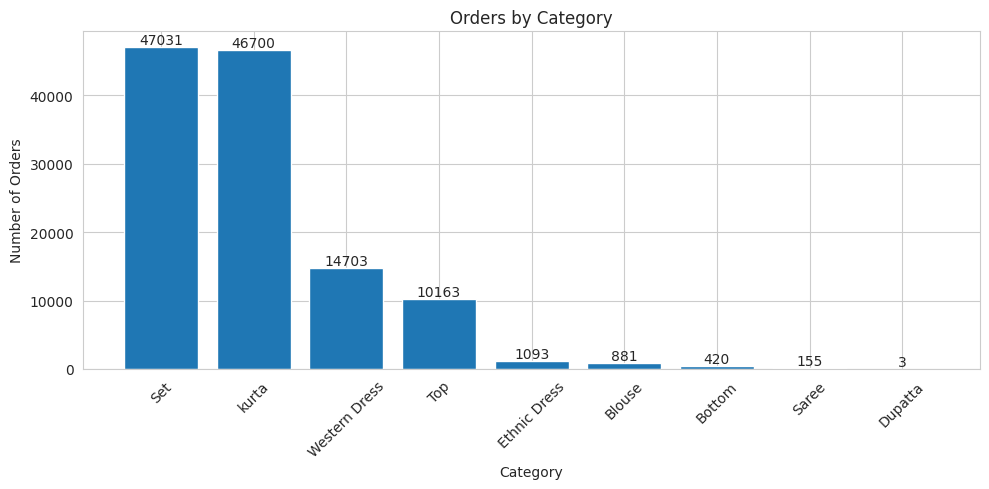

In [157]:
# Chart - 4 visualization code
category_orders = df_clean['Category'].value_counts()

plt.figure(figsize=(10,5))

bars = plt.bar(category_orders.index, category_orders.values)

# Add count labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             int(bar.get_height()),
             ha='center', va='bottom')

plt.title('Orders by Category')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it is the most suitable visualization for comparing the number of orders across different product categories. It clearly highlights which categories receive the highest and lowest order volumes.

##### 2. What is/are the insight(s) found from the chart?

* Set (47,031 orders) and Kurta (46,700 orders) are the two most ordered product categories, indicating they are the primary drivers of customer demand.
* Western Dress (14,703 orders) and Top (10,163 orders) have moderate order volumes but are significantly lower than the top two categories.
* Categories such as Ethnic Dress, Blouse, Bottom, Saree, and Dupatta contribute very few orders, with Dupatta receiving only 3 orders, suggesting extremely low customer demand.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights help the business prioritize inventory and marketing efforts toward high-demand categories like Set and Kurta, ensuring product availability and maximizing sales. At the same time, the very low demand for categories such as Dupatta, Saree, and Bottom indicates that the business should review their pricing, product assortment, or promotional strategies to improve performance or reconsider inventory allocation for these products.

#### Chart - 5 - Category-wise Sales Amount (Bar Chart)


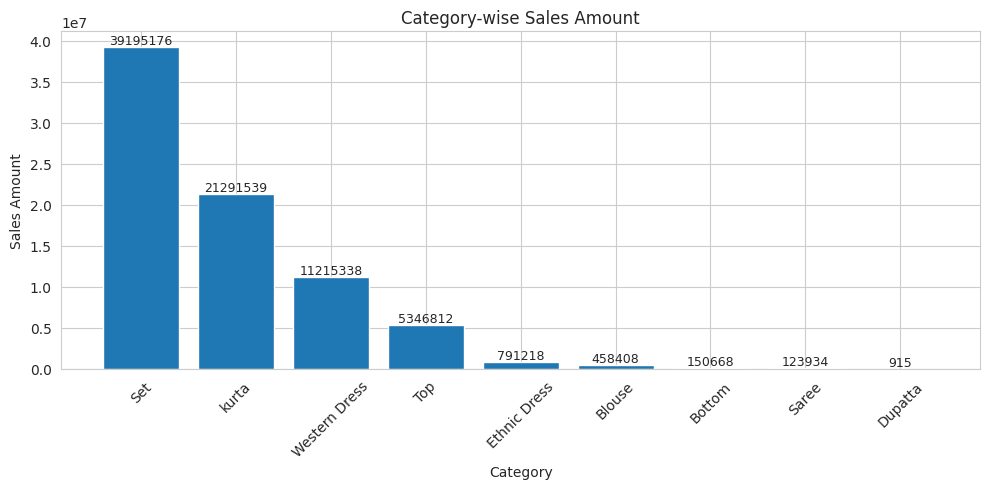

In [158]:
# Chart - 5 visualization code
category_sales = df_clean.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

bars = plt.bar(category_sales.index, category_sales.values)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Category-wise Sales Amount')
plt.xlabel('Category')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it is the most suitable visualization for comparing the total sales amount across different product categories. It provides a clear comparison of revenue generated by each category, making it easy to identify the highest and lowest revenue contributors.

##### 2. What is/are the insight(s) found from the chart?

* Set generated the highest sales amount (39,195,176), making it the top revenue-contributing category.
* Kurta (21,291,539) and Western Dress (11,215,338) were the second and third highest revenue-generating categories, while Top contributed a moderate sales amount (5,346,812).
* Categories such as Ethnic Dress, Blouse, Bottom, Saree, and Dupatta generated comparatively low sales, with Dupatta contributing only 915, indicating minimal revenue from this category.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The analysis identifies the categories that contribute the most to overall revenue, enabling the business to prioritize inventory, marketing, and promotional efforts for high-performing categories like Set and Kurta. The low revenue generated by categories such as Dupatta and Saree suggests that the business should review their product assortment, pricing strategy, or promotional activities to improve sales or optimize inventory allocation.

#### Chart - 6 - Quantity Sold by Category (Bar Chart)


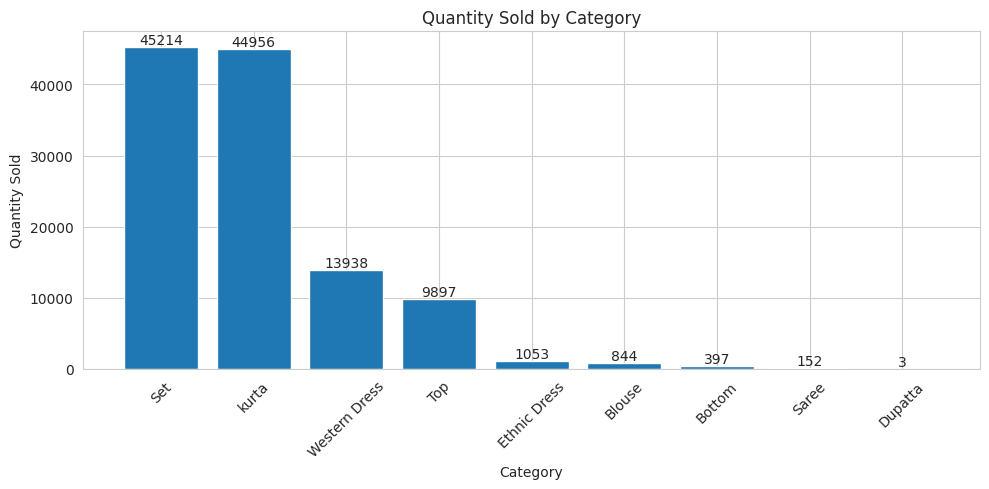

In [159]:
# Chart - 6 visualization code
category_qty = df_clean.groupby('Category')['Qty'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

bars = plt.bar(category_qty.index, category_qty.values)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             int(bar.get_height()),
             ha='center', va='bottom')

plt.title('Quantity Sold by Category')
plt.xlabel('Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it provides a clear comparison of the total quantity sold across different product categories. It helps identify which categories have the highest and lowest sales volume, making comparisons straightforward.

##### 2. What is/are the insight(s) found from the chart?

* Set recorded the highest quantity sold (45,214 units), followed closely by Kurta (44,956 units), indicating these are the most in-demand product categories.
* Western Dress (13,938 units) and Top (9,897 units) showed moderate sales volumes compared to the leading categories.
* Categories such as Ethnic Dress (1,053 units), Blouse (844 units), Bottom (397 units), Saree (152 units), and Dupatta (3 units) sold very few units, indicating comparatively lower customer demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps the business identify the categories with the highest customer demand, enabling better inventory planning and stock management. High-selling categories such as Set and Kurta can be prioritized to maximize sales, while low-selling categories can be reviewed for pricing, product assortment, or promotional strategies to improve their performance and optimize inventory allocation.

#### Chart - 7 - Top 10 Best Selling Stock Keeping Units (Horizontal Bar Chart)

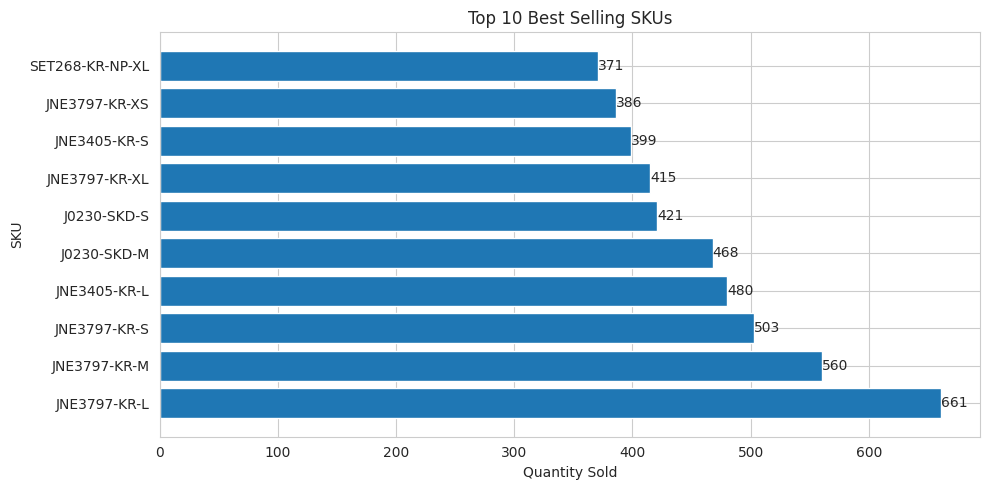

In [160]:
# Chart - 7 visualization code
top_skus = df_clean.groupby('SKU')['Qty'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

bars = plt.barh(top_skus.index, top_skus.values)

for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             int(bar.get_width()),
             va='center')

plt.title('Top 10 Best Selling SKUs')
plt.xlabel('Quantity Sold')
plt.ylabel('SKU')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was chosen because SKU names are long and difficult to display on a vertical axis. This chart clearly ranks the top 10 best-selling SKUs by quantity sold, making comparisons easier to read and interpret.

##### 2. What is/are the insight(s) found from the chart?

* JNE3797-KR-L is the best-selling SKU with 661 units sold, followed by JNE3797-KR-M (560 units) and JNE3797-KR-S (503 units).
* The JNE3797 series appears multiple times in the top 10 list, indicating that different size variants of this product are consistently in high demand.
* The difference in sales among the top 10 SKUs is relatively small (from 371 to 661 units), suggesting that customer demand is distributed across several popular products rather than being concentrated on a single SKU.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying the best-selling SKUs helps the business maintain adequate inventory for high-demand products and reduce the chances of stockouts. It also enables better demand forecasting and supports targeted marketing campaigns for popular SKUs. The strong performance of the JNE3797 product variants suggests that similar products or additional size variants could be promoted to further increase sales.

#### Chart - 8 - Top 10 Styles by Quantity Sold (Horizontal Bar Chart)

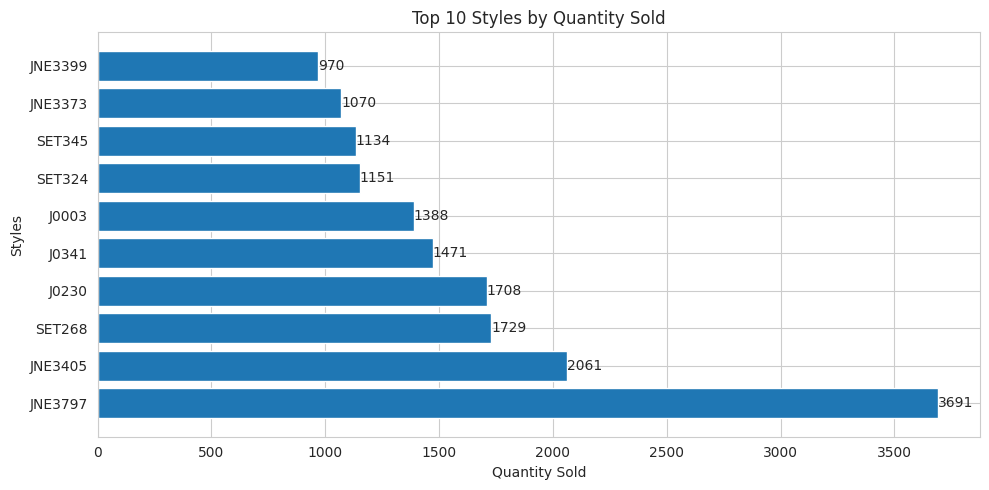

In [161]:
# Chart - 8 visualization code
top_styles = df_clean.groupby('Style')['Qty'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

bars = plt.barh(top_styles.index, top_styles.values)

for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             int(bar.get_width()),
             va='center')

plt.title('Top 10 Styles by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Styles')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was chosen because it effectively ranks product styles by the quantity sold. Since style names are easier to compare horizontally, this chart clearly highlights the best-performing styles.

##### 2. What is/are the insight(s) found from the chart?

* JNE3797 is the best-selling style with 3,691 units sold, significantly outperforming all other styles.
* JNE3405 (2,061 units), SET268 (1,729 units), and J0230 (1,708 units) are the next most popular styles, indicating strong customer demand.
* The remaining styles sold between 970 and 1,471 units, suggesting that while they contribute to sales, their demand is considerably lower than the top-selling styles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying the top-selling styles helps the business understand customer preferences and prioritize the production, inventory, and promotion of high-demand designs such as JNE3797 and JNE3405. Focusing on these popular styles can improve inventory planning, reduce stock shortages, and increase overall sales, while lower-performing styles can be reviewed for design improvements or targeted promotional campaigns.

### Type 3 - Customer Purchase Behaviour Analysis


#### Chart - 9 - Size Distribution (Count Plot)


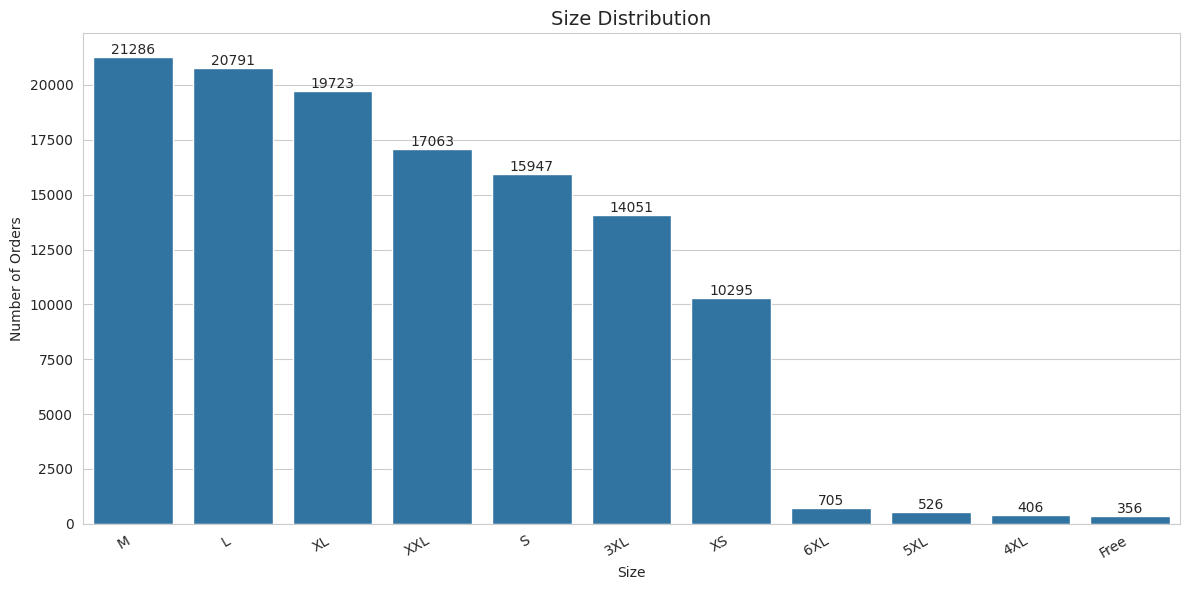

In [162]:
# Chart - 9 visualization code
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df_clean,
    x='Size',
    order=df_clean['Size'].value_counts().index,
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Size Distribution', fontsize=14)
plt.xlabel('Size')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because Size is a categorical variable. It clearly shows the frequency of orders for each size, making it easy to compare customer preferences and identify the most and least demanded sizes.

##### 2. What is/are the insight(s) found from the chart?

* M (21,286 orders), L (20,791 orders), and XL (19,723 orders) are the most frequently ordered sizes, indicating the highest customer demand.
* Sizes XXL (17,063 orders), S (15,947 orders), and 3XL (14,051 orders) also have substantial demand, showing that customers purchase a wide range of sizes.
* Very large sizes such as 4XL (406 orders), 5XL (526 orders), 6XL (705 orders), and Free Size (356 orders) have significantly fewer orders, indicating comparatively lower demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps the business optimize inventory by maintaining higher stock levels for popular sizes such as M, L, and XL, reducing the risk of stock shortages. At the same time, the relatively low demand for larger and free sizes suggests that inventory for these sizes can be managed more efficiently, helping reduce excess stock while still meeting customer needs.

#### Chart - 10 - B2B vs B2C Orders (Pie Chart)

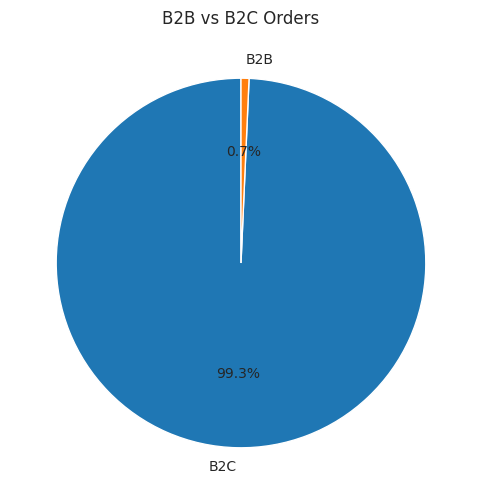

In [163]:
# Chart - 10 visualization code
b2b_orders = df_clean['B2B'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    b2b_orders,
    labels=['B2C', 'B2B'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('B2B vs B2C Orders')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was chosen because the B2B column has only two categories (B2B and B2C). It effectively shows the proportion of orders placed by each customer segment, making it easy to understand their contribution to total orders.

##### 2. What is/are the insight(s) found from the chart?

* B2C orders account for 99.3% of all orders, indicating that the vast majority of customers are individual consumers.
* B2B orders contribute only 0.7%, showing that business-to-business transactions form a very small portion of the total orders.
* The order distribution is highly skewed towards the B2C segment, suggesting that the company's primary customer base is retail consumers rather than business clients.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Since almost all orders come from B2C customers, the business should continue focusing on consumer-oriented marketing campaigns, customer experience, and product offerings. At the same time, the very small share of B2B orders indicates an opportunity to expand into the business market through bulk purchase programs, corporate partnerships, or special pricing for business customers.

#### Chart - 11 - Promotion vs Non-Promotion Orders (Pie Chart)


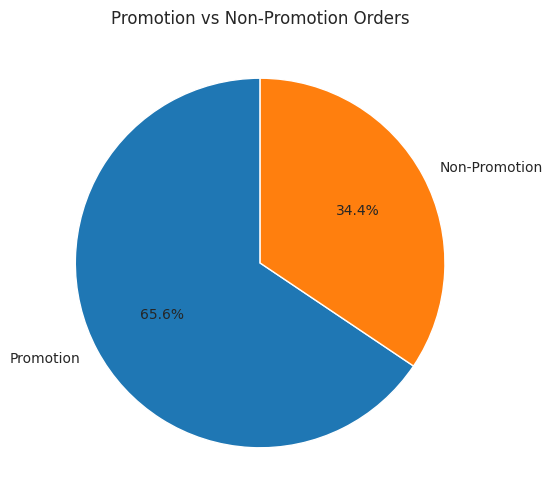

In [164]:
# Chart - 11 visualization code
promotion = df_clean['promotion-ids'].notna().map({
    True: 'Promotion',
    False: 'Non-Promotion'
}).value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    promotion,
    labels=promotion.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Promotion vs Non-Promotion Orders')

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was chosen because the data consists of two categories—Promotion and Non-Promotion orders. It effectively displays the proportion of orders placed with and without promotional offers, making the comparison easy to understand.

##### 2. What is/are the insight(s) found from the chart?

* 65.6% of the orders were placed using promotional offers, while 34.4% were placed without any promotion.
* The majority of customers purchased products during promotional campaigns, indicating that discounts and offers have a significant influence on buying behavior.
* Although promotional orders dominate, over one-third of the orders were made without promotions, suggesting that many customers are willing to purchase products at regular prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The high percentage of promotion-based orders indicates that promotional campaigns are effective in attracting customers and increasing sales. The business can continue using targeted discounts during peak shopping periods while also focusing on product quality, pricing, and customer experience to encourage more purchases without relying heavily on promotions. This balanced approach can improve both sales volume and profitability.

### Type 4 - Geographic Analysis


#### Chart - 12 - Top 10 States by Sales Amount (Horizontal Bar Chart)

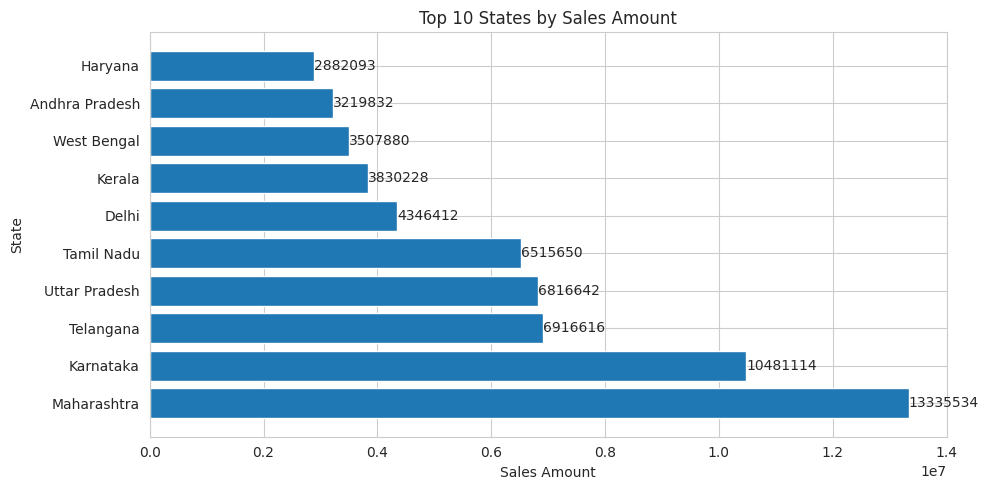

In [165]:
# Chart - 12 visualization code
top_states = (df_clean.groupby('ship-state')['Amount']
              .sum()
              .sort_values(ascending=False)
              .head(10))

plt.figure(figsize=(10,5))

bars = plt.barh(top_states.index, top_states.values)

for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.0f}',
             va='center')

plt.title('Top 10 States by Sales Amount')
plt.xlabel('Sales Amount')
plt.ylabel('State')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was chosen because it effectively compares the total sales amount across multiple states. The horizontal layout improves the readability of state names and clearly ranks the top 10 states by revenue.

##### 2. What is/are the insight(s) found from the chart?

* Maharashtra generated the highest sales amount (13,335,534), followed by Karnataka (10,481,114), making them the two largest revenue-contributing states.
* Telangana (6,916,616), Uttar Pradesh (6,816,642), and Tamil Nadu (6,515,650) also contributed significantly to total sales, indicating strong customer demand in these regions.
* Haryana (2,882,093) recorded the lowest sales amount among the top 10 states, while states such as Delhi, Kerala, West Bengal, and Andhra Pradesh generated moderate revenue.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying the highest revenue-generating states enables the business to focus its inventory, logistics, and marketing efforts on key markets such as Maharashtra and Karnataka. Additionally, states with comparatively lower sales among the top 10 can be targeted with region-specific promotions and marketing campaigns to increase customer reach and improve revenue growth.

#### Chart - 13 - Top 10 Cities by Number of Orders (Horizontal Bar Chart)

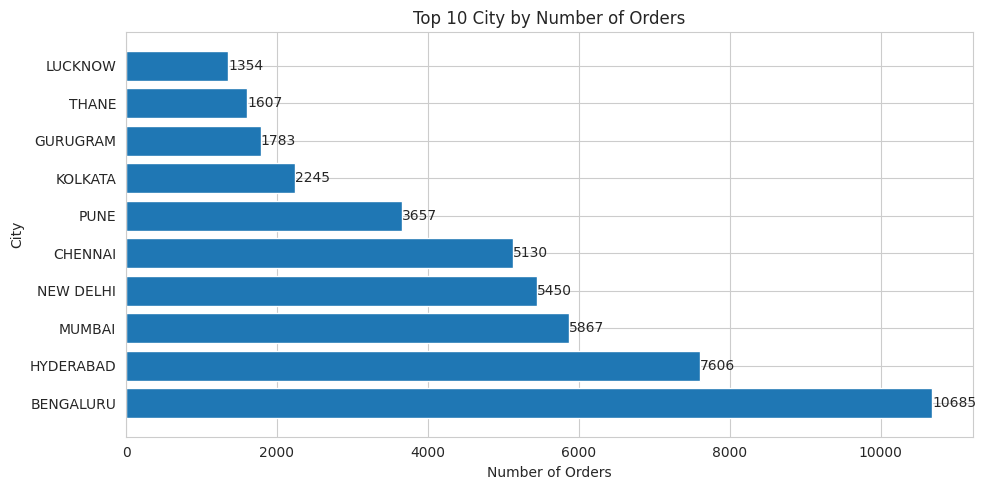

In [166]:
# Chart - 13 visualization code
top_city = df_clean['ship-city'].value_counts().head(10)

plt.figure(figsize=(10,5))

bars = plt.barh(top_city.index, top_city.values)

for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.0f}',
             va='center')

plt.title('Top 10 City by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('City')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was chosen because it clearly ranks the top 10 cities by the number of orders. The horizontal layout makes city names easy to read and allows for quick comparison of order volumes across different cities.

##### 2. What is/are the insight(s) found from the chart?

* Bengaluru recorded the highest number of orders (10,685), followed by Hyderabad (7,606), making them the two largest order-generating cities.
* Mumbai (5,867), New Delhi (5,450), and Chennai (5,130) also contributed a substantial number of orders, indicating strong customer demand in major metropolitan cities.
* Pune (3,657), Kolkata (2,245), Gurugram (1,783), Thane (1,607), and Lucknow (1,354) completed the top 10, showing that orders are concentrated primarily in large urban areas.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying the cities with the highest number of orders helps the business optimize inventory allocation, warehouse planning, and delivery operations. High-demand cities such as Bengaluru and Hyderabad can be prioritized for faster deliveries, targeted marketing campaigns, and improved customer service, while cities with comparatively lower order volumes can be targeted through localized promotions to increase sales and customer engagement.

#### Chart - 14 - Top 10 State Average Order Value (Bar Chart)

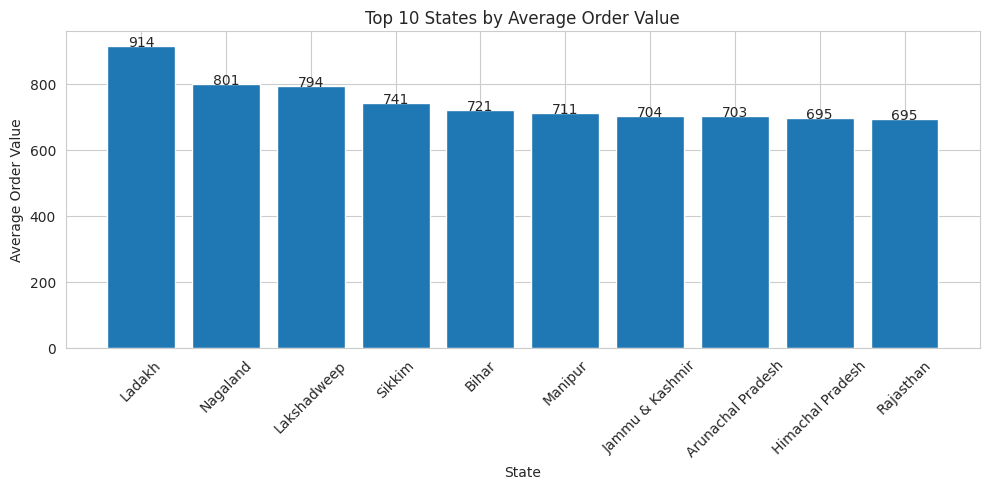

In [168]:
# Chart - 14 visualization code
aov = (df_clean.groupby('ship-state')['Amount']
       .mean()
       .sort_values(ascending=False)
       .head(10))

plt.figure(figsize=(10,5))

bars = plt.bar(aov.index, aov.values)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.0f}',
             ha='center')

plt.title('Top 10 States by Average Order Value')
plt.xlabel('State')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it effectively compares the average order value (AOV) across different states. It helps identify the states where customers spend more per order, making comparisons straightforward.

##### 2. What is/are the insight(s) found from the chart?

* Ladakh recorded the highest average order value (914), indicating that customers in this state spend the most per order on average.
* Nagaland (801) and Lakshadweep (794) also have relatively high average order values, suggesting that customers in these regions tend to place higher-value orders.
* The remaining states, including Sikkim (741), Bihar (721), Manipur (711), Jammu & Kashmir (704), Arunachal Pradesh (703), Himachal Pradesh (695), and Rajasthan (695), have average order values within a similar range, indicating relatively consistent customer spending.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the average order value by state helps the business identify regions where customers are willing to spend more per purchase. These states can be targeted with premium products, personalized recommendations, and upselling strategies. For states with comparatively lower average order values, the business can introduce product bundles, cross-selling, or promotional offers to encourage customers to increase their purchase value.

#### Chart - 1

In [ ]:
# Chart - 1 visualization code


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 1

In [ ]:
# Chart - 1 visualization code


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 1

In [ ]:
# Chart - 1 visualization code


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 1

In [ ]:
# Chart - 1 visualization code


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 1

In [ ]:
# Chart - 1 visualization code


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 14 - Correlation Heatmap

In [81]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [82]:
# Pair Plot visualization code

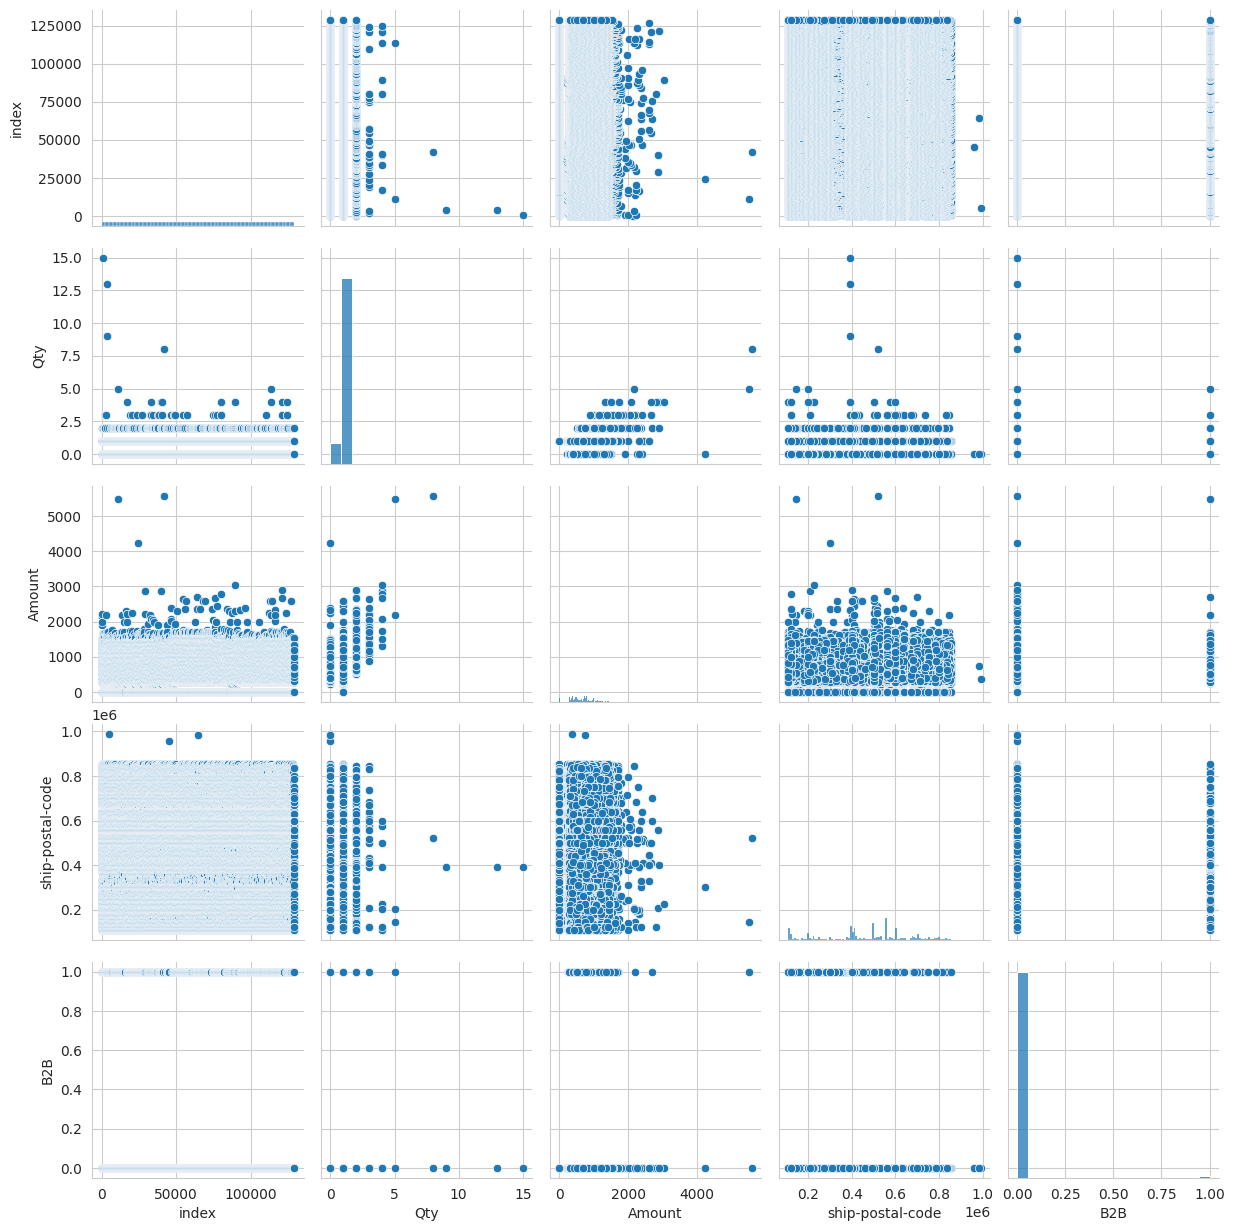

In [83]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***